
We are one of the fastest growing startups in the logistics and delivery domain. We work with several partners and make on-demand delivery to our customers. From operational standpoint we have been facing several different challenges and everyday we are trying to address these challenges.

We thrive on making our customers happy. As a growing startup, with a global expansion strategy we know that we need to make our customers happy and the only way to do that is to measure how happy each customer is. If we can predict what makes our customers happy or unhappy, we can then take necessary actions.

Getting feedback from customers is not easy either, but we do our best to get constant feedback from our customers. This is a crucial function to improve our operations across all levels.

We recently did a survey to a select customer cohort. You are presented with a subset of this data. We will be using the remaining data as a private test set.

**Data Description:**

Y = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers</br>
X1 = my order was delivered on time</br>
X2 = contents of my order was as I expected</br>
X3 = I ordered everything I wanted to order</br>
X4 = I paid a good price for my order</br>
X5 = I am satisfied with my courier</br>
X6 = the app makes ordering easy for me</br>

Attributes X1 to X6 indicate the responses for each question and have values from 1 to 5 where the smaller number indicates less and the higher number indicates more towards the answer.

**Goal(s):**

Predict if a customer is happy or not based on the answers they give to questions asked.

**Success Metrics:**

Reach 73% accuracy score or above, or convince us why your solution is superior. We are definitely interested in every solution and insight you can provide us.

Try to submit your working solution as soon as possible. The sooner the better.

**Bonus(es):**

We are very interested in finding which questions/features are more important when predicting a customer’s happiness. Using a feature selection approach show us understand what is the minimal set of attributes/features that would preserve the most information about the problem while increasing predictability of the data we have. Is there any question that we can remove in our next survey?

In [2]:
import warnings

warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np


# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)


# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
from sklearn.metrics import (
     f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)


In [16]:
# Installing the libraries with the specified version.
#!pip install pandas==1.5.3 numpy==1.25.2 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 statsmodels==0.14.1 -q --user

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
Review= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ACME-HappinessSurvey2020.csv')

In [5]:
data=Review.copy()

## Data Overview

- Observations
- Sanity checks

In [9]:
data.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [10]:
data.tail()

,Y,X1,X2,X3,X4,X5,X6
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5
125,0,5,3,2,5,5,5


In [12]:
data.shape


(126, 7)

* 126 rows and 7 columns

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


* All column data type is integer and there is no null values.

In [14]:
data.describe()

,Y,X1,X2,X3,X4,X5,X6
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


* On time order delivery mean rating is 4.33 and apps makes ordering easy mean rating is 4.25
* Expectation of content mean rating is lowest among all rating which is 2.5.
* All ratings are between 1 and 5.

In [17]:
data.isnull().sum()

,0
Y,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0


* There is no null value in the data.

In [10]:
data['Y'].value_counts(normalize=True)

,proportion
Y,
1,0.547619
0,0.452381


* About 55% of the customers are happy and 45% are unhappy.

In [12]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=60, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

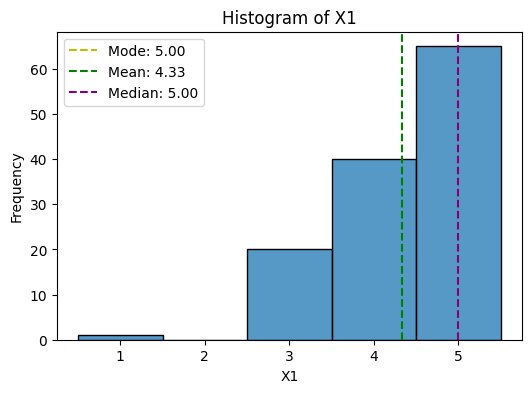

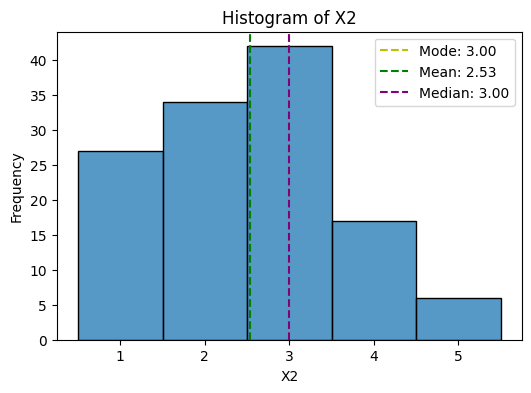

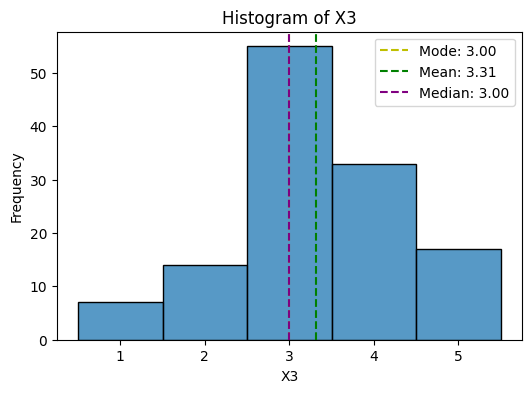

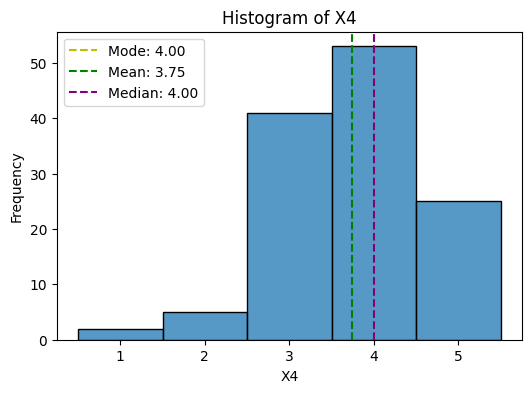

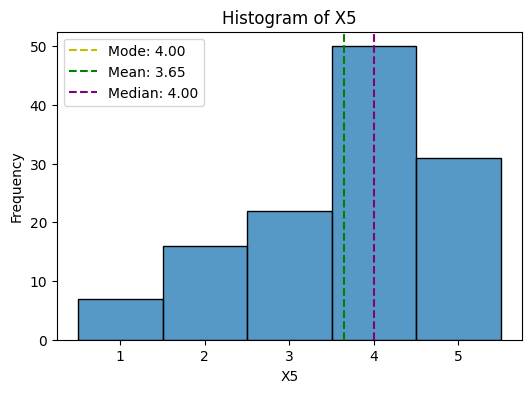

In [6]:

# Define the columns of interest.
columns = ["X1", "X2", "X3", "X4", "X5"]

# Iterate over the columns to create the histograms.
for column in columns:
    # Calculate quartiles, mean and mode.
    Q1 = data[column].quantile(0.25)
    Q2 = data[column].median()
    mean = data[column].mean()
    Q3 = data[column].quantile(0.75)
    mode = data[column].mode()[0]

    # Create a figure for each histogram
    plt.figure(figsize=(6, 4))

    # Graph settings
    sns.histplot(data[column], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], kde=False)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Add lines for Q1, Q2, median, Q3 , mode
    plt.axvline(mode, color='y', linestyle='--', label=f'Mode: {mode:.2f}')

    plt.axvline(mean, color='g', linestyle='--', label=f'Mean: {mean:.2f}')

    plt.axvline(Q2, color='purple', linestyle='--', label=f'Median: {Q2:.2f}')
    # Show leyend
    plt.legend()

    # Show graph
    plt.show()

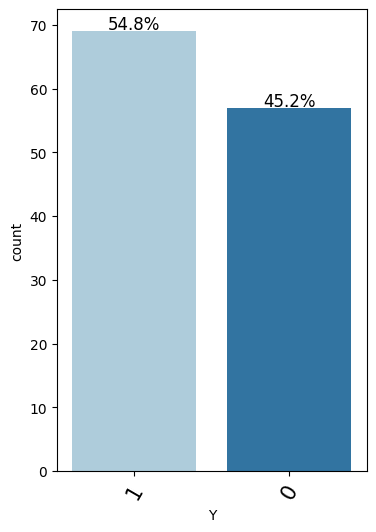

In [13]:
labeled_barplot(data,"Y", perc=True)

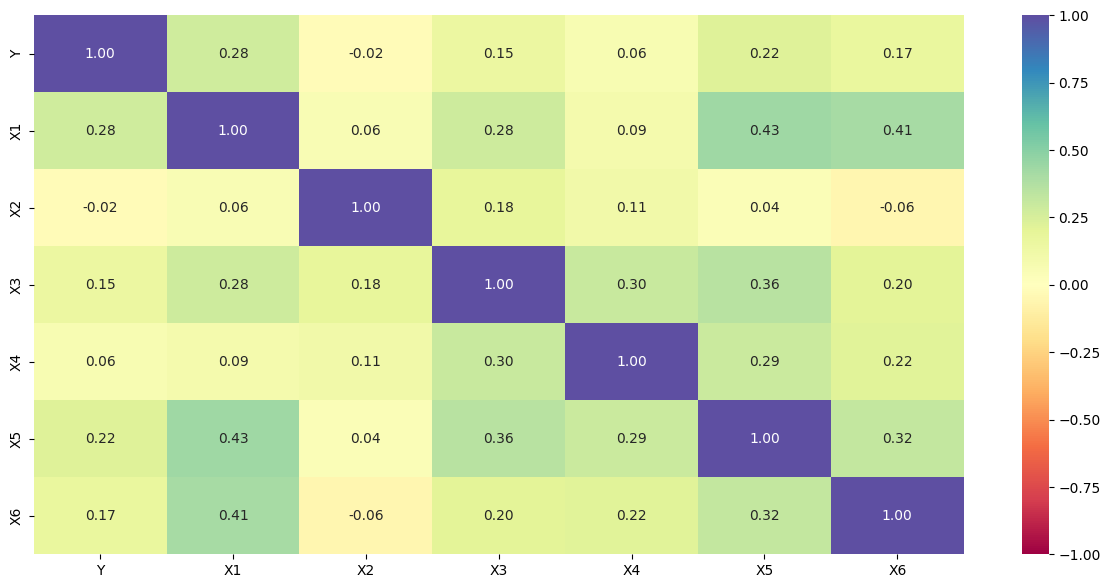

In [7]:
plt.figure(figsize=(15, 7))
# Selecting only numerical features for correlation analysis
numerical_data = data.select_dtypes(include=np.number)
sns.heatmap(numerical_data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* There is no strong corelation betweeen independent variables and dependent variable "y".
* There is a corelation possitive corelation between X1 and X5, and X1 and X6 which means order delivery on time makes customer satisfied with the courier service.

<Axes: xlabel='X1', ylabel='count'>

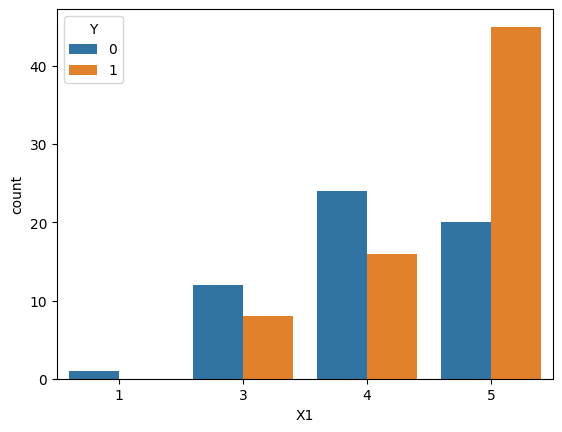

In [8]:
sns.countplot(data=data, x='X1', hue='Y')

<Axes: xlabel='X2', ylabel='count'>

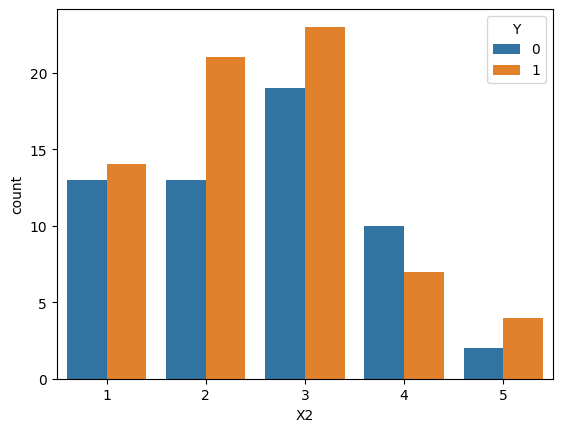

In [35]:
sns.countplot(data=data, x='X2', hue='Y')

<Axes: xlabel='X3', ylabel='count'>

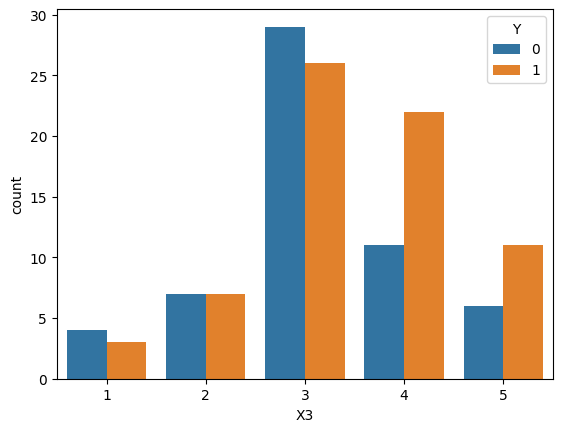

In [36]:
sns.countplot(data=data, x='X3', hue='Y')

<Axes: xlabel='X4', ylabel='count'>

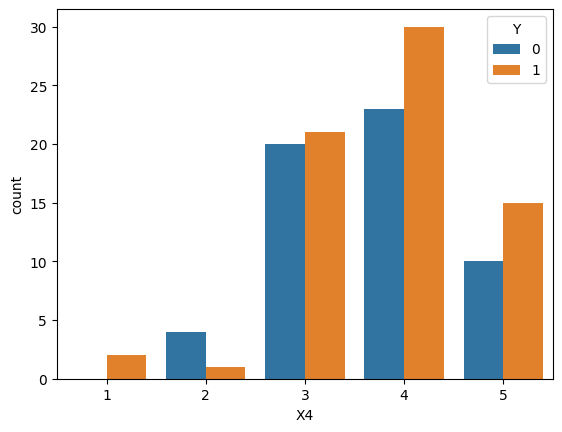

In [37]:
sns.countplot(data=data, x='X4', hue='Y')

<Axes: xlabel='X5', ylabel='count'>

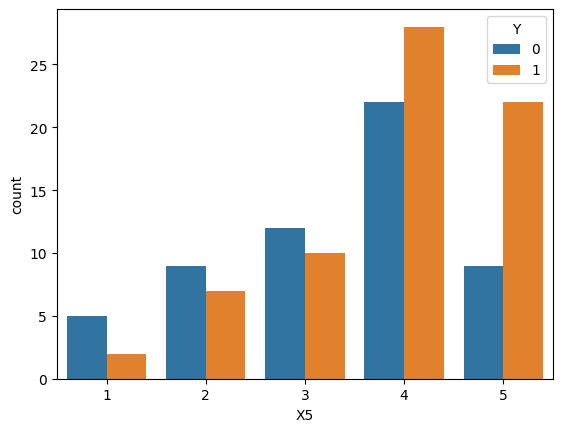

In [38]:
sns.countplot(data=data, x='X5', hue='Y')

<Axes: xlabel='X6', ylabel='count'>

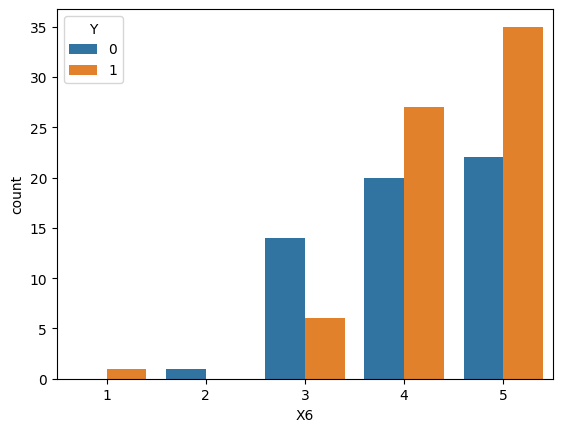

In [39]:
sns.countplot(data=data, x='X6', hue='Y')

In [9]:
# specifying the independent  and dependent variables
X = data.drop(["Y"], axis=1)
Y = data["Y"]
# adding a constant to the independent variables

X = sm.add_constant(X)


# splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=42)

In [67]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (88, 6)
Shape of test set :  (38, 6)
Percentage of classes in training set:
Y
1    0.579545
0    0.420455
Name: proportion, dtype: float64
Percentage of classes in test set:
Y
0    0.526316
1    0.473684
Name: proportion, dtype: float64


In [51]:
data.shape

(126, 7)

In [10]:
data.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


**Checking Multicollinearity**
In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

In [11]:
vif_series = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
    dtype=float,
)
print("VIF values: \n\n{}\n".format(vif_series))

VIF values: 

const    62.132802
X1        1.327478
X2        1.047496
X3        1.261223
X4        1.165803
X5        1.255996
X6        1.283947
dtype: float64



**Building a Logistic Regression model**

In [12]:
# fitting the model on training set
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit(disp=False)
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       81
Method:                           MLE   Df Model:                            6
Date:                Fri, 20 Feb 2026   Pseudo R-squ.:                 0.09811
Time:                        03:37:13   Log-Likelihood:                -54.004
converged:                       True   LL-Null:                       -59.879
Covariance Type:            nonrobust   LLR p-value:                   0.06781
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8825      1.834     -2.117      0.034      -7.476      -0.289
X1             1.0405      0.389      2.673      0.008       0.278       1.803
X2            -0.1972      0.208     -0.949      0.3

In [13]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [14]:
# defining a function to plot the confusion_matrix of a classification model


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

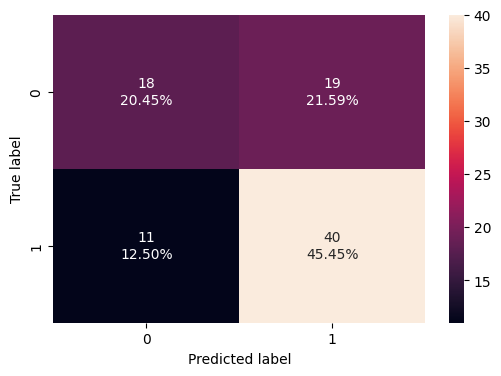

In [15]:
confusion_matrix_statsmodels(lg, X_train, y_train)

In [16]:
print("Training performance:")
model_performance_classification_statsmodels(lg, X_train, y_train)

Training performance:


,Accuracy,Recall,Precision,F1
0,0.659091,0.784314,0.677966,0.727273


In [17]:
# initial list of columns
cols = X_train.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = X_train[cols]

    # fitting the model
    model = sm.Logit(y_train, X_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'X1']


In [18]:
X_train2 = X_train[selected_features]

In [19]:
logit1 = sm.Logit(y_train, X_train2.astype(float))
lg1 = logit1.fit(disp=False)

print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       86
Method:                           MLE   Df Model:                            1
Date:                Fri, 20 Feb 2026   Pseudo R-squ.:                 0.08902
Time:                        03:37:36   Log-Likelihood:                -54.548
converged:                       True   LL-Null:                       -59.879
Covariance Type:            nonrobust   LLR p-value:                  0.001095
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.1893      1.482     -2.827      0.005      -7.094      -1.285
X1             1.0301      0.334      3.081      0.002       0.375       1.685


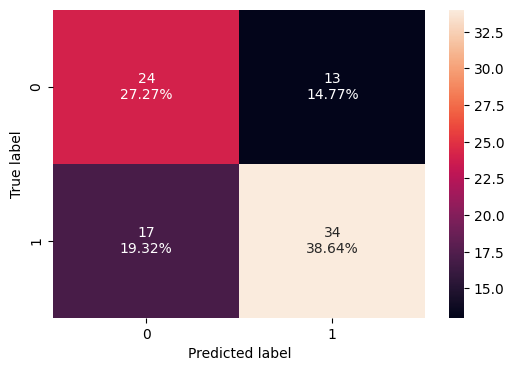

In [20]:
# creating confusion matrix
confusion_matrix_statsmodels(lg1, X_train2, y_train)

In [21]:
# converting coefficients to odds
odds = np.exp(lg1.params)

# finding the percentage change
perc_change_odds = (np.exp(lg1.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train2.columns).T

,const,X1
Odds,0.015157,2.801436
Change_odd%,-98.484348,180.143554


In [22]:
log_reg_model_train_perf = model_performance_classification_statsmodels(
    lg1, X_train2, y_train
)

print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.659091,0.666667,0.723404,0.693878
